In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Ogrenci_ID': range(1, 18), # 1'den 17'ye kadar ID verir
    'Ders_Adi': ['Bulanik_Mantik'] * 17, # Hepsine aynı ders adını yazar
    'Haftalik_Ders_Saati': [3] * 17, # Sabit değer (değiştirebilirsin)
    'AKTS': [6] * 17,                # Sabit değer
    'Tekrar_Sayisi': [0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 0, 0, 3, 0, 1], # 0: İlk kez
    
    # --- REGRESYON İÇİN KRİTİK OLAN 2 SÜTUN ---
    'Calisma_Saati': [1, 1, 0.5, 3, 3, 1, 1, 0, 4, 0.25, 0.5, 0.25, 0, 1, 3, 1, 2], 
    'Basari_Puani':  [80, 100, 100, 52, 80, 73, 73, 100, 66, 20, 14, 31, 85, 95, 80, 71, 70]
}

# Veriyi tabloya (DataFrame) çeviriyoruz
df = pd.DataFrame(data)

# Tabloyu gör
df

,Ogrenci_ID,Ders_Adi,Haftalik_Ders_Saati,AKTS,Tekrar_Sayisi,Calisma_Saati,Basari_Puani
0,1,Bulanik_Mantik,3,6,0,1.00,80
1,2,Bulanik_Mantik,3,6,0,1.00,100
2,3,Bulanik_Mantik,3,6,0,0.50,100
3,4,Bulanik_Mantik,3,6,0,3.00,52
4,5,Bulanik_Mantik,3,6,0,3.00,80
5,6,Bulanik_Mantik,3,6,0,1.00,73
6,7,Bulanik_Mantik,3,6,0,1.00,73
7,8,Bulanik_Mantik,3,6,0,0.00,100
8,9,Bulanik_Mantik,3,6,0,4.00,66
9,10,Bulanik_Mantik,3,6,3,0.25,20


In [4]:
# Regresyon modelleri için X ve y'yi ayırma
X = df[['Calisma_Saati']]                     # Çift parantez önemli (DataFrame formatı için)
y = df['Basari_Puani']

print("Veriler analize hazır.")

Veriler analize hazır.


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# Verileri modele uygun formata getiriyoruz (X 2 boyutlu, y 1 boyutlu olmalı)
X = df[['Calisma_Saati']].values
y = df['Basari_Puani'].values

# Ödevde tahmin etmemiz istenen saatler (0.5, 1.0, 1.5, 2.0)
tahmin_edilecek_saatler = np.array([[0.5], [1.0], [1.5], [2.0]])

print("Kütüphaneler yüklendi ve veriler hazır.")

Kütüphaneler yüklendi ve veriler hazır.


In [6]:
# --- MODEL 1: Basit Doğrusal Regresyon (Linear Regression) ---
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_lin = lin_reg.predict(tahmin_edilecek_saatler)

# --- MODEL 2: Polinom Regresyon (Polynomial Regression - 2. Derece) ---
poly_feat = PolynomialFeatures(degree=2)
X_poly = poly_feat.fit_transform(X) # X verisini polinoma çevir (karesini al vb.)
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
# Tahmin için girdiğimiz saatleri de polinoma çevirmeliyiz
tahmin_poly = poly_feat.transform(tahmin_edilecek_saatler) 
y_pred_poly = poly_reg.predict(tahmin_poly)

# --- MODEL 3: Destek Vektör Regresyonu (SVR - Support Vector Regression) ---
# Kernel='rbf' doğrusal olmayan ilişkileri yakalar
svr_reg = SVR(kernel='rbf', C=100, gamma='auto') 
svr_reg.fit(X, y)
y_pred_svr = svr_reg.predict(tahmin_edilecek_saatler)

print("Modeller başarıyla eğitildi.")

Modeller başarıyla eğitildi.


In [7]:
print(f"{'Saat':<10} {'Lineer Tahmin':<15} {'Polinom Tahmin':<15} {'SVR Tahmin':<15}")
print("-" * 55)

for i in range(len(tahmin_edilecek_saatler)):
    saat = tahmin_edilecek_saatler[i][0]
    p_lin = y_pred_lin[i]
    p_poly = y_pred_poly[i]
    p_svr = y_pred_svr[i]
    print(f"{saat:<10} {p_lin:<15.2f} {p_poly:<15.2f} {p_svr:<15.2f}")

Saat       Lineer Tahmin   Polinom Tahmin  SVR Tahmin     
-------------------------------------------------------
0.5        69.08           68.58           66.14          
1.0        69.64           72.90           73.10          
1.5        70.20           75.51           77.05          
2.0        70.76           76.42           70.10          


In [8]:
# 1. SORU: İlişki var mı? (R-Kare Skoru)
# Lineer modelin başarısına bakalım (1'e ne kadar yakınsa ilişki o kadar güçlüdür)
r2 = r2_score(y, lin_reg.predict(X))

print("--- RAPOR İÇİN CEVAPLAR ---")
print(f"Soru 1: İlişki Var mı? -> R^2 Değeri: {r2:.2f}")
if r2 > 0.7:
    print("  Yorum: Evet, çalışma saati ile puan arasında GÜÇLÜ bir ilişki var.")
elif r2 > 0.4:
    print("  Yorum: Evet, ORTA düzeyde bir ilişki var.")
else:
    print("  Yorum: İlişki zayıf veya yok.")

# 2. SORU: 1 saatlik çalışmanın etkisi nedir?
# Bu, Lineer Regresyon denklemindeki 'katsayı'dır (coefficient/slope).
etki = lin_reg.coef_[0]

print(f"\nSoru 2: 1 saatlik ekstra çalışma puanı ne kadar etkiliyor?")
print(f"  Cevap: Ortalama {etki:.2f} puan artırıyor.")

--- RAPOR İÇİN CEVAPLAR ---
Soru 1: İlişki Var mı? -> R^2 Değeri: 0.00
  Yorum: İlişki zayıf veya yok.

Soru 2: 1 saatlik ekstra çalışma puanı ne kadar etkiliyor?
  Cevap: Ortalama 1.12 puan artırıyor.


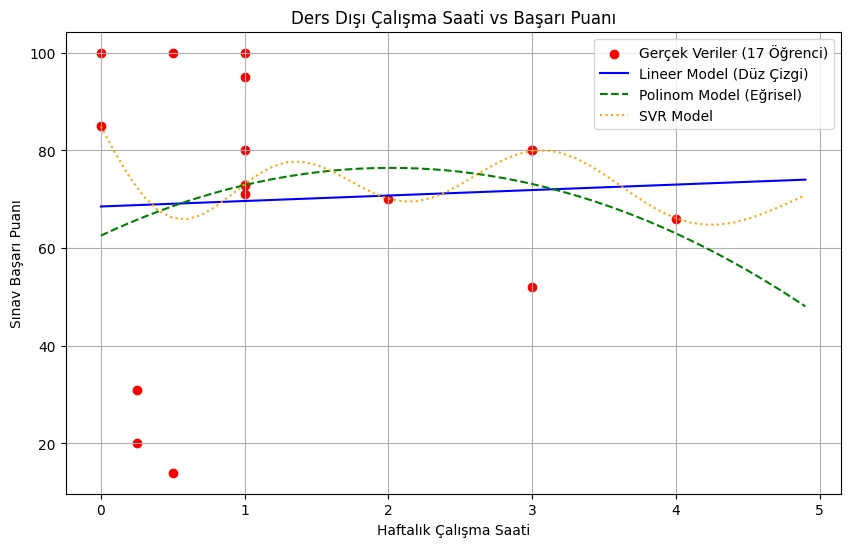

In [9]:
# Grafik çizimi
plt.figure(figsize=(10, 6))

# Gerçek verileri nokta olarak çiz
plt.scatter(df['Calisma_Saati'], df['Basari_Puani'], color='red', label='Gerçek Veriler (17 Öğrenci)')

# Modellerin çizimini yapmak için aralıklı veriler üretelim (0 ile 5 saat arası)
X_grid = np.arange(0, 5, 0.1).reshape(-1, 1)

# 1. Lineer Çizgi
plt.plot(X_grid, lin_reg.predict(X_grid), color='blue', label='Lineer Model (Düz Çizgi)')

# 2. Polinom Eğrisi
plt.plot(X_grid, poly_reg.predict(poly_feat.transform(X_grid)), color='green', linestyle='--', label='Polinom Model (Eğrisel)')

# 3. SVR Eğrisi
plt.plot(X_grid, svr_reg.predict(X_grid), color='orange', linestyle=':', label='SVR Model')

plt.title('Ders Dışı Çalışma Saati vs Başarı Puanı')
plt.xlabel('Haftalık Çalışma Saati')
plt.ylabel('Sınav Başarı Puanı')
plt.legend()
plt.grid(True)
plt.show()